# World Happiness Report — Visualisations
Requires `happiness_clean.csv` produced by `main_analysis.ipynb`.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
df = pd.read_csv('happiness_clean.csv')
print(df.shape)
df.head(3)

(2116, 22)


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,...,dystopia_plus_residual,tier,has_breakdown,score_change_yoy,region,years_in_dataset,coverage_pct,score_std,z_score,is_outlier
0,2011,131,Afghanistan,4.258,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Bottom,False,NaN,South Asia,14,100.0,0.95,-1.032,False
1,2012,143,Afghanistan,4.040,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Bottom,False,-0.218,South Asia,14,100.0,0.95,-1.251,False
2,2014,153,Afghanistan,3.575,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Bottom,False,-0.465,South Asia,14,100.0,0.95,-1.573,False


## 1  Global score distribution by year

C:\Users\Matvey\AppData\Local\Temp\ipykernel_22616\715547655.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years, patch_artist=True, notch=False)


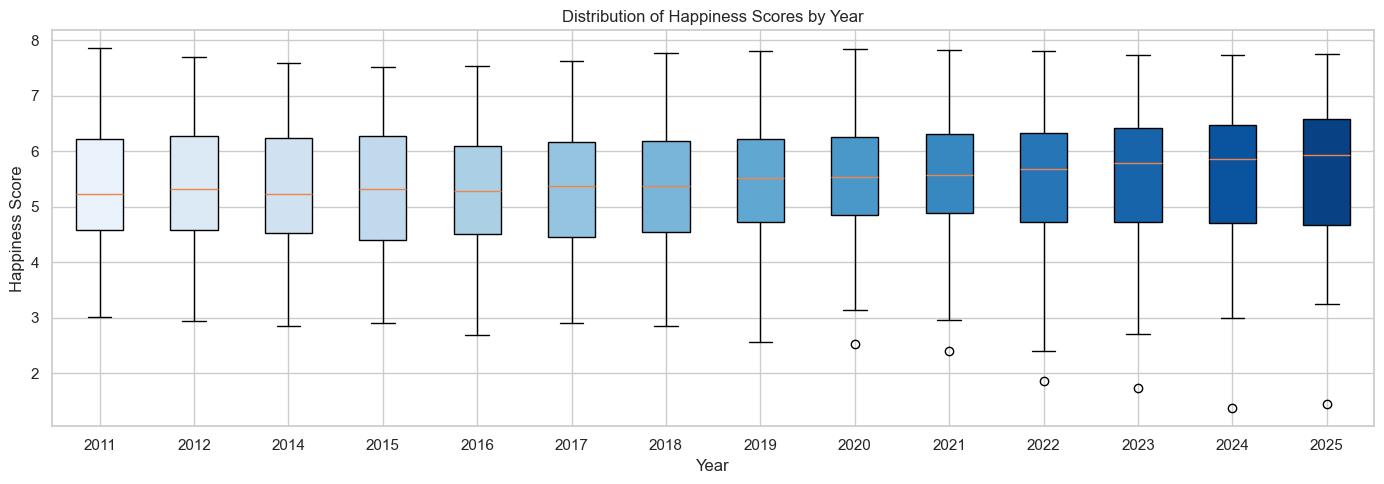

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
years = sorted(df['year'].unique())
data_by_year = [df.loc[df['year'] == y, 'happiness_score'].values for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True, notch=False)
colors = sns.color_palette('Blues', len(years))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Distribution of Happiness Scores by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Happiness Score')
plt.tight_layout()
plt.savefig('plot_score_distribution.png', dpi=150)
plt.show()

## 2  Top 10 countries in 2025

In [ ]:
top10 = df[df['year'] == 2025].nsmallest(10, 'rank_in_year').sort_values('happiness_score')
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top10['country'], top10['happiness_score'], color=sns.color_palette('Greens_d', 10))
mask = top10['lower_whisker'].notna()
if mask.any():
    sub_eb = top10[mask]
    xerr = [sub_eb['happiness_score'] - sub_eb['lower_whisker'],
            sub_eb['upper_whisker'] - sub_eb['happiness_score']]
    ax.errorbar(sub_eb['happiness_score'], sub_eb['country'], xerr=xerr,
                fmt='none', color='black', capsize=4)
ax.set_title('Top 10 Happiest Countries — 2025')
ax.set_xlabel('Happiness Score')
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.tight_layout()
plt.savefig('plot_top10_2025.png', dpi=150)
plt.show()

## 3  Trend lines for selected countries

In [ ]:
COUNTRIES = ['Finland', 'Denmark', 'United States', 'Ukraine', 'Afghanistan', 'China']
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', len(COUNTRIES))
for country, color in zip(COUNTRIES, palette):
    sub = df[df['country'] == country].sort_values('year')
    ax.plot(sub['year'], sub['happiness_score'], marker='o', label=country, color=color)

for yr, label in [(2020, 'COVID-19'), (2022, 'Ukraine invasion')]:
    ax.axvline(yr, color='#555', lw=1.2, ls=':', alpha=0.8)
    ax.text(yr + 0.1, 0.97, label, color='#555', fontsize=8, va='top',
            transform=ax.get_xaxis_transform())

ax.set_title('Happiness Score Trends — Selected Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Happiness Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_trends.png', dpi=150)
plt.show()

## 4  Stacked bar — factor breakdown for top 15 (2025)

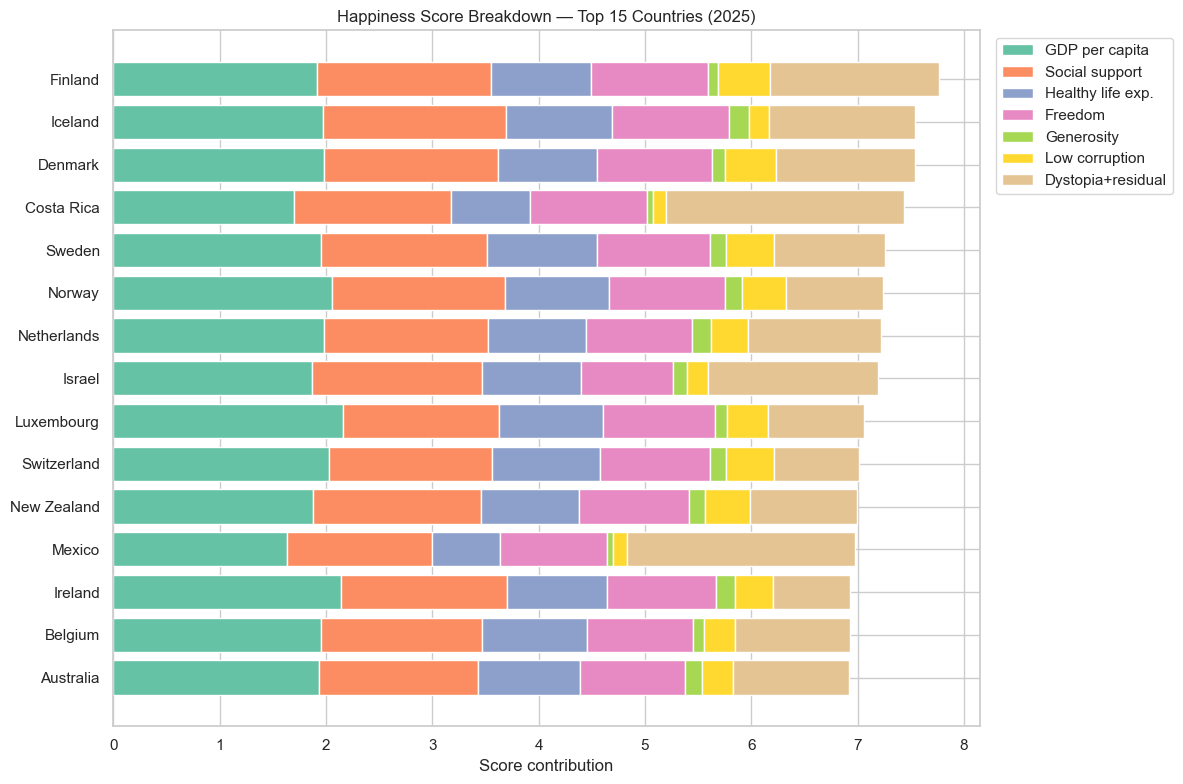

In [12]:
breakdown_cols = [
    'explained_log_gdp_per_capita', 'explained_social_support',
    'explained_healthy_life_expectancy', 'explained_freedom',
    'explained_generosity', 'explained_corruption', 'dystopia_plus_residual'
]
nice_labels = ['GDP per capita', 'Social support', 'Healthy life exp.',
               'Freedom', 'Generosity', 'Low corruption', 'Dystopia+residual']

top15 = (df[(df['year'] == 2025) & df['has_breakdown']]
         .nsmallest(15, 'rank_in_year')
         .sort_values('happiness_score', ascending=True))

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('Set2', len(breakdown_cols))
left = np.zeros(len(top15))
for col, label, color in zip(breakdown_cols, nice_labels, palette):
    ax.barh(top15['country'], top15[col], left=left, label=label, color=color)
    left += top15[col].values
ax.set_title('Happiness Score Breakdown — Top 15 Countries (2025)')
ax.set_xlabel('Score contribution')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_breakdown_top15.png', dpi=150)
plt.show()

## 5  Correlation heatmap (2025 breakdown columns)

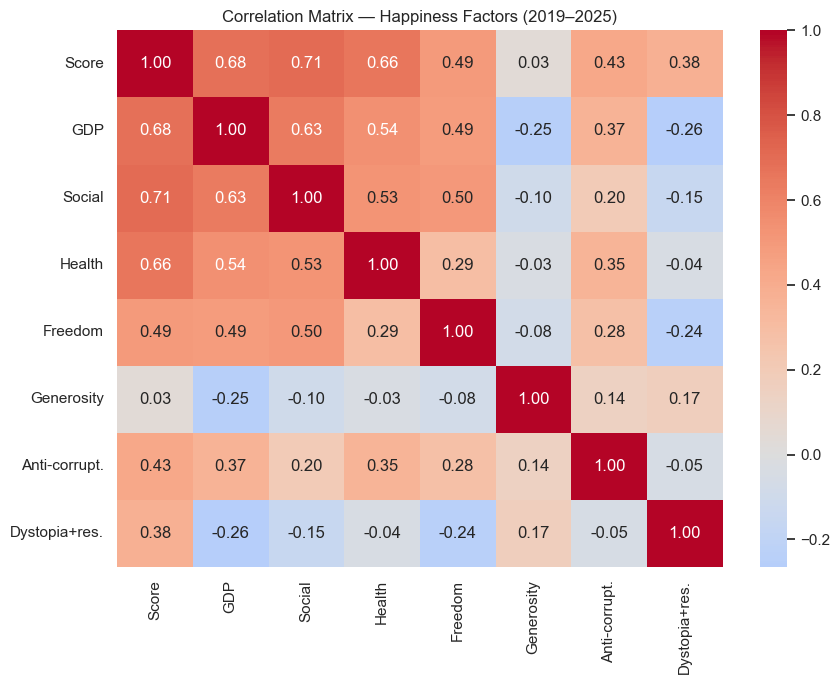

In [13]:
corr_df = df[df['has_breakdown']][['happiness_score'] + breakdown_cols].copy()
corr_df.columns = ['Score', 'GDP', 'Social', 'Health', 'Freedom', 'Generosity', 'Anti-corrupt.', 'Dystopia+res.']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Happiness Factors (2019–2025)')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150)
plt.show()

## 6  Rank change heatmap (2011 → 2025)

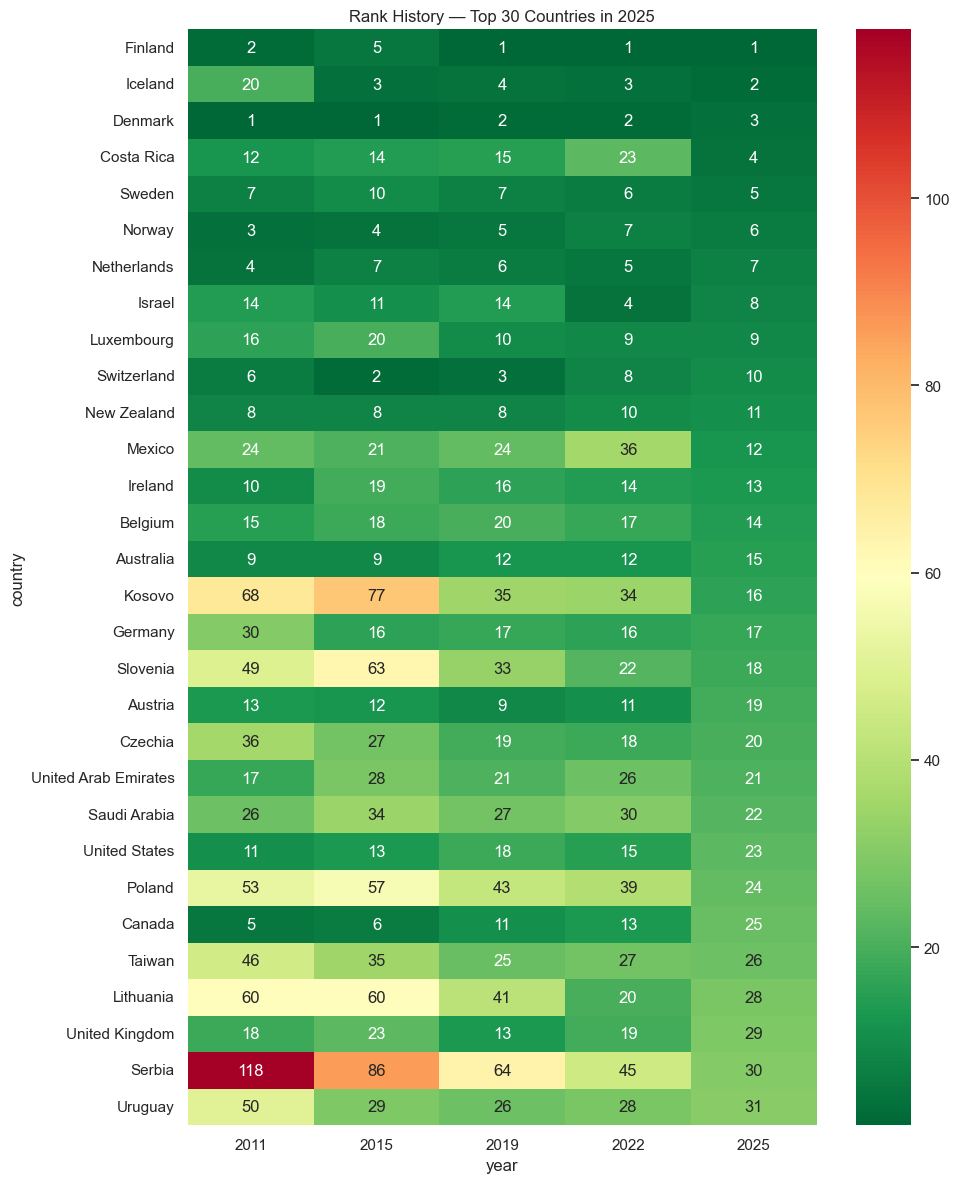

In [14]:
pivot = df[df['year'].isin([2011, 2015, 2019, 2022, 2025])].pivot_table(
    index='country', columns='year', values='rank_in_year'
)
# Only countries present in all 5 selected years
pivot = pivot.dropna()
# Sort by 2025 rank
pivot = pivot.sort_values(2025)
top30 = pivot.head(30)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(top30, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Rank History — Top 30 Countries in 2025')
plt.tight_layout()
plt.savefig('plot_rank_heatmap.png', dpi=150)
plt.show()

## 7  Regional happiness trends (2011–2025)

In [ ]:
region_trend = (df.groupby(['region', 'year'])['happiness_score']
                .mean()
                .reset_index())
regions = sorted(region_trend['region'].unique())
palette = sns.color_palette('tab10', len(regions))

fig, ax = plt.subplots(figsize=(14, 6))
for region, color in zip(regions, palette):
    sub = region_trend[region_trend['region'] == region]
    ax.plot(sub['year'], sub['happiness_score'], marker='o', lw=2, ms=5,
            label=region, color=color)

for yr, label in [(2020, 'COVID-19'), (2022, 'Ukraine\ninvasion')]:
    ax.axvline(yr, color='#555', lw=1, ls=':', alpha=0.7)
    ax.text(yr + 0.1, 0.97, label, color='#555', fontsize=7.5, va='top',
            transform=ax.get_xaxis_transform())

ax.set_title('Mean Happiness Score by Region (2011–2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Happiness Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('plot_regional_trends.png', dpi=150)
plt.show()

## 8  Biggest movers: 2011 → 2025

In [ ]:
scores_2011 = df[df['year'] == 2011].set_index('country')['happiness_score']
scores_2025 = df[df['year'] == 2025].set_index('country')['happiness_score']
common = scores_2011.index.intersection(scores_2025.index)
change = (scores_2025[common] - scores_2011[common]).rename('change').reset_index()
change.columns = ['country', 'change']

movers = pd.concat([change.nlargest(10, 'change'), change.nsmallest(10, 'change')]).sort_values('change')

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#2ca02c' if x > 0 else '#d62728' for x in movers['change']]
bars = ax.barh(movers['country'], movers['change'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, movers['change']):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_title('Biggest Movers: Happiness Score Change 2011 → 2025\n(countries present in both years)')
ax.set_xlabel('Score change')
plt.tight_layout()
plt.savefig('plot_biggest_movers.png', dpi=150)
plt.show()

## 9  Score volatility vs mean happiness

In [ ]:
per_country = df.drop_duplicates('country')[['country', 'region', 'score_std', 'years_in_dataset']].copy()
mean_score = df.groupby('country')['happiness_score'].mean().rename('mean_score')
per_country = per_country.merge(mean_score, on='country')

regions = sorted(per_country['region'].dropna().unique())
palette = {r: c for r, c in zip(regions, sns.color_palette('tab10', len(regions)))}

fig, ax = plt.subplots(figsize=(12, 7))
for region in regions:
    sub = per_country[per_country['region'] == region]
    ax.scatter(sub['mean_score'], sub['score_std'],
               s=sub['years_in_dataset'] * 10,
               color=palette[region], label=region, alpha=0.7, edgecolors='white', lw=0.4)

for _, row in per_country.nlargest(6, 'score_std').iterrows():
    ax.annotate(row['country'], (row['mean_score'], row['score_std']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Mean Happiness Score (2011–2025)')
ax.set_ylabel('Score Std Dev (volatility)')
ax.set_title('Score Volatility vs Mean Happiness\n(bubble size = years in dataset)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('plot_volatility_scatter.png', dpi=150)
plt.show()